# Introducción y Objetivos del Proyecto
---

### Contexto de Negocio
El presente análisis se enfoca en la identificación temprana de clientes con alta probabilidad de clasificar en la categoría **Dirty 1** (Mora confirmada/Default). La correcta detección de estos casos es crítica para la entidad, ya que representan el segmento de mayor pérdida financiera y riesgo reputacional.

### Objetivos Técnicos
* **Predicción de Clasificación Dirty 1:** Desarrollar un modelo de **Regresión Logística (Logit)** capaz de asignar una probabilidad de pertenencia a este grupo de riesgo extremo basándose en el historial transaccional y el perfil del cliente.
* **Optimización de Variables (Parsimonia):** Refinar un set inicial de 26 variables hasta obtener un modelo de 13 predictores significativos, utilizando transformaciones logarítmicas (`LN`) para linealizar la relación con el logit de la probabilidad de default.
* **Estrategia de Decisión:** Determinar el umbral óptimo (threshold) que maximice la captura de casos **Dirty 1** reales, minimizando los falsos negativos que impactan directamente en las previsiones del banco.

### Métricas de Éxito
Se evaluará la robustez del modelo mediante el **Estadístico KS** (apuntando a una separación superior a 0.40) y el **Área Bajo la Curva ROC (AUC)**, asegurando que el modelo tenga un alto poder discriminante entre clientes "Clean" y "Dirty 1".

# 2. Preparación del Entorno y Carga de Datos
---
En esta sección se configuran las herramientas analíticas necesarias para el desarrollo del modelo. Se utilizan librerías estándar de la industria para el tratamiento de estructuras de datos, visualización estadística y la implementación de modelos lineales generalizados (GLM).

### 2.1. Importación de Librerías
* **Pandas & Numpy:** Fundamentales para la manipulación de DataFrames y operaciones vectorizadas.
* **Matplotlib & Seaborn:** Librerías de cabecera para la generación de diagnósticos visuales y matrices de confusión.
* **Statsmodels:** Utilizada como motor principal para el ajuste del modelo Logit, permitiendo un análisis riguroso de significancia estadística ($P > |z|$).
* **Sklearn:** Empleada para la partición de la muestra (Train/Test) y el cálculo de métricas de performance (ROC, AUC, KS).

### 2.2. Lectura del Dataset
Se procede a la carga del archivo fuente que contiene la información histórica de los clientes, sus atributos demográficos y su clasificación final (Clean / Dirty 1).

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Configuración estética de los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga de datos 
df = pd.read_csv(r'E:\OneDrive\Maestria en Estadistica\11 - Analisis Multivariado\Trabajo final\banco\Banco.csv',sep=';')

# Verificación inicial de la estructura
df

,id,ANTIGUEDAD,SALDO_TOTAL,SALDO_RESUMEN,CANT_TARJETAS,EDAD,ESTADO_CIVIL,SEXO,CUENTA_BASICA,INGRESOS_NETOS,MAXIMA_MORA,ENDEUDAMIENTO,SIT_MAYOR1,SEGMENTO,SITUACION,DIRTY
0,1,78,"1465,53","1465,53",1,84,Viudo/a,FEMENINO,0,"8647,64",11,"0,00",0,JUBILADO NACION,1,0
1,2,102,"31104,20","8184,04",1,75,Viudo/a,FEMENINO,0,"25330,44",11,"0,26",0,JUBILADO NACION,1,0
2,3,51,"30274,75","3281,90",1,79,Casado/a,FEMENINO,0,"9718,30",7,"0,25",0,JUBILADO NACION,0,0
3,4,114,"2883,86","2883,86",1,85,Viudo/a,FEMENINO,0,"19585,07",6,"0,00",0,JUBILADO NACION,0,0
4,5,69,"0,00","0,00",1,71,Soltero/a,FEMENINO,0,"17472,75",8,"0,00",0,JUBILADO NACION,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6912,6913,17,"58308,46","8723,14",2,39,Casado/a,MASCULINO,0,"48031,21",55,"0,68",1,CONVENIO,3,1
6913,6914,11,"64481,98","19734,18",1,28,Soltero/a,FEMENINO,0,"21384,19",0,"0,53",13,CONVENIO,3,0
6914,6915,111,"10402,87","2887,59",2,63,Soltero/a,FEMENINO,0,"57657,86",44,"0,29",4,JUBILADO NACION,1,0
6915,6916,70,"156792,80","119363,34",2,60,Casado/a,MASCULINO,0,"102695,17",8,"0,42",3,INDEFINIDOS,1,0


In [47]:
df.describe()

,id,ANTIGUEDAD,CANT_TARJETAS,EDAD,CUENTA_BASICA,MAXIMA_MORA,SIT_MAYOR1,SITUACION,DIRTY
count,6917.000000,6917.000000,6917.000000,6917.00000,6917.000000,6917.000000,6917.000000,6917.000000,6917.000000
mean,3459.000000,75.247506,1.127512,51.97976,0.045829,6.891571,1.946942,0.913835,0.097441
std,1996.910238,36.044680,0.502960,14.78713,0.209129,16.755646,4.802904,1.070845,0.296579
min,1.000000,0.000000,0.000000,20.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1730.000000,44.000000,1.000000,40.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3459.000000,86.000000,1.000000,52.00000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,5188.000000,111.000000,1.000000,64.00000,0.000000,4.000000,1.000000,1.000000,0.000000
max,6917.000000,115.000000,3.000000,96.00000,1.000000,138.000000,25.000000,5.000000,1.000000


# 3. Preparación, Limpieza y Validación de Supuestos
---


In [48]:
# Definir las columnas que requieren conversión de formato regional
cols_monetarias = ['SALDO_TOTAL', 'SALDO_RESUMEN', 'INGRESOS_NETOS', 'ENDEUDAMIENTO']

# Iterar sobre cada columna para normalizar el formato decimal
for col in cols_monetarias:
    # Reemplazar la coma por punto y convertir a tipo flotante
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

# Verificar que los tipos de datos ahora permitan realizar cálculos
print(df[cols_monetarias].dtypes)

SALDO_TOTAL       float64
SALDO_RESUMEN     float64
INGRESOS_NETOS    float64
ENDEUDAMIENTO     float64
dtype: object


In [49]:
# Aplicar la regla de negocio para los valores faltantes en el BCRA
# Asignar 0 para representar una situación crediticia normal
df['SIT_MAYOR1'] = df['SIT_MAYOR1'].fillna(0).astype(int)

# Confirmar la eliminación de valores nulos en esta columna
print(f"Nulos en SIT_MAYOR1: {df['SIT_MAYOR1'].isnull().sum()}")

Nulos en SIT_MAYOR1: 0


In [50]:
# Definir la variable objetivo (Target) para la regresión logística
# Utilizar 'DIRTY' como indicador de mal comportamiento crediticio (1 = Malo, 0 = Bueno)
# Esta variable captura situaciones irregulares en los últimos 24 meses 

# Crear una copia de la columna para claridad en el modelo
df['target'] = df['DIRTY'].astype(int)

# Realizar un conteo de la distribución de clases
# Es fundamental para identificar si existe un desbalanceo de datos
distribucion_target = df['target'].value_counts(normalize=True) * 100

print("Distribución de la Variable Objetivo (%):")
print(distribucion_target)

# Verificación de consistencia con otras variables de riesgo
# Cruzar el target con SITUACION para validar la lógica del negocio [cite: 20]
print("\nCruce de Target vs SITUACION (Frecuencias):")
print(pd.crosstab(df['target'], df['SITUACION']))

Distribución de la Variable Objetivo (%):
target
0    90.255891
1     9.744109
Name: proportion, dtype: float64

Cruce de Target vs SITUACION (Frecuencias):
SITUACION     0     1    2    3   4    5
target                                  
0          2283  3430  238  108  85   99
1           183   211   67   50  54  109


In [51]:
df[df['INGRESOS_NETOS'] == 0]

,id,ANTIGUEDAD,SALDO_TOTAL,SALDO_RESUMEN,CANT_TARJETAS,EDAD,ESTADO_CIVIL,SEXO,CUENTA_BASICA,INGRESOS_NETOS,MAXIMA_MORA,ENDEUDAMIENTO,SIT_MAYOR1,SEGMENTO,SITUACION,DIRTY,target
18,19,62,3343.77,2649.58,1,83,Viudo/a,MASCULINO,0,0.0,34,315.33,0,JUBILADO NACION,0,0,0
97,98,12,5167.02,2608.06,1,81,Soltero/a,FEMENINO,0,0.0,91,0.00,0,JUBILADO NACION,3,1,1
219,220,96,4081.16,3463.10,1,65,Casado/a,FEMENINO,0,0.0,1,538.65,0,CONVENIO,1,0,0
312,313,55,9913.53,1748.77,1,64,Soltero/a,FEMENINO,0,0.0,0,337.08,0,CONVENIO,1,0,0
342,343,28,6482.51,2364.42,2,65,Soltero/a,MASCULINO,0,0.0,3,1265.58,0,INDEFINIDOS,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6901,6902,79,7160.73,7160.73,0,41,Divorciado/a,MASCULINO,0,0.0,24,0.00,10,JUBILADO NACION,1,1,1
6902,6903,7,81598.36,57004.83,1,39,Soltero/a,MASCULINO,0,0.0,10,8374.97,0,JUBILADO NACION,0,1,1
6903,6904,57,23737.25,2994.90,1,38,Soltero/a,FEMENINO,0,0.0,34,1464.58,0,CONVENIO,1,0,0
6907,6908,10,37413.85,35486.69,1,26,Soltero/a,MASCULINO,0,0.0,0,8352.74,3,CONVENIO,0,1,1


### **Detección y Tratamiento de Inconsistencias en Ingresos**

#### ** Justificación de la detección**
Antes de proceder con el entrenamiento de la **Regresión Logística**, es imperativo auditar la variable `INGRESOS_NETOS`. La detección de valores en $0$ es crítica por dos razones técnicas fundamentales:

* **Validez del Ratio de Endeudamiento:** La variable `ENDEUDAMIENTO` se define como $\frac{\text{Cuotas}}{\text{Ingresos}}$. Matemáticamente, un ingreso de $0$ genera un ratio indeterminado o infinito, lo que imposibilita al modelo encontrar un coeficiente estable para esta variable.
* **Integridad de Negocio:** Un titular de tarjeta con consumos activos y saldos pendientes difícilmente posea ingresos nulos reales; esto suele representar una falla en la captura o carga de los datos. Mantener estos registros introduciría "ruido", sesgando las probabilidades de *default* calculadas por el algoritmo.

#### ** Análisis de Frecuencias e Identificación**
Ejecutar el siguiente bloque para cuantificar el impacto de los ingresos nulos en la muestra:



In [52]:
# Analizar la presencia de ingresos en cero
conteo_ingresos_cero = (df['INGRESOS_NETOS'] == 0).sum()
porcentaje_cero = (conteo_ingresos_cero / len(df)) * 100

print(f"Cantidad de registros con ingreso 0: {conteo_ingresos_cero}")
print(f"Porcentaje sobre el total de la muestra: {porcentaje_cero:.2f}%")

# Visualizar el comportamiento de endeudamiento en estos casos
print("\nEstadísticas de ENDEUDAMIENTO para casos con ingreso 0:")
print(df[df['INGRESOS_NETOS'] == 0]['ENDEUDAMIENTO'].describe())

Cantidad de registros con ingreso 0: 391
Porcentaje sobre el total de la muestra: 5.65%

Estadísticas de ENDEUDAMIENTO para casos con ingreso 0:
count      391.000000
mean      3347.457161
std       5653.772593
min          0.000000
25%          0.000000
50%       1615.300000
75%       4601.115000
max      66273.400000
Name: ENDEUDAMIENTO, dtype: float64


#### ** Evaluación de Alternativas**
Para gestionar este **5%** de inconsistencias, evaluar las siguientes vías de acción:
1.  **Imputación por Mediana:** Reemplazar los ceros por el ingreso promedio del segmento del cliente. Permite conservar el volumen de datos pero puede diluir patrones de riesgo extremos.
2.  **Sustitución por valor mínimo ($1$):** Descartada por generar *outliers* artificiales en el ratio de endeudamiento, rompiendo la escala del modelo.
3.  **Eliminación de registros (Drop):** Remover las filas afectadas para asegurar que el modelo trabaje únicamente con información verificable y coherente.

#### ** Decisión Técnica: Eliminación de Registros**
Optar por **eliminar los registros con ingresos en cero**. Al representar solo el $5\%$ de la base, la pérdida de volumen es despreciable frente a la ganancia en precisión y robustez estadística. Esta acción garantiza que la variable de solvencia más importante (`ENDEUDAMIENTO`) sea matemáticamente válida para todos los individuos de la muestra.


In [53]:
# Aplicar la depuración de la base de datos
# Filtrar para mantener solo registros con ingresos positivos coherentes
df_limpio = df[df['INGRESOS_NETOS'] > 0].copy()

# Validar la dimensión final de la muestra para el modelado
print(f"Registros eliminados: {len(df) - len(df_limpio)}")
print(f"Muestra final para entrenamiento: {df_limpio.shape[0]}")

# Verificar que el ratio de endeudamiento ahora posea valores operables
print("\nResumen del ratio de endeudamiento tras la limpieza:")
print(df_limpio['ENDEUDAMIENTO'].describe())

Registros eliminados: 391
Muestra final para entrenamiento: 6526

Resumen del ratio de endeudamiento tras la limpieza:
count    6526.000000
mean        0.285762
std         0.633308
min         0.000000
25%         0.080000
50%         0.220000
75%         0.380000
max        19.250000
Name: ENDEUDAMIENTO, dtype: float64


**Observación:** Tras ejecutar este filtro, la base de datos queda preparada para la fase de ingeniería de variables, contando con una distribución de ingresos y capacidad de pago realista para el sector bancario.

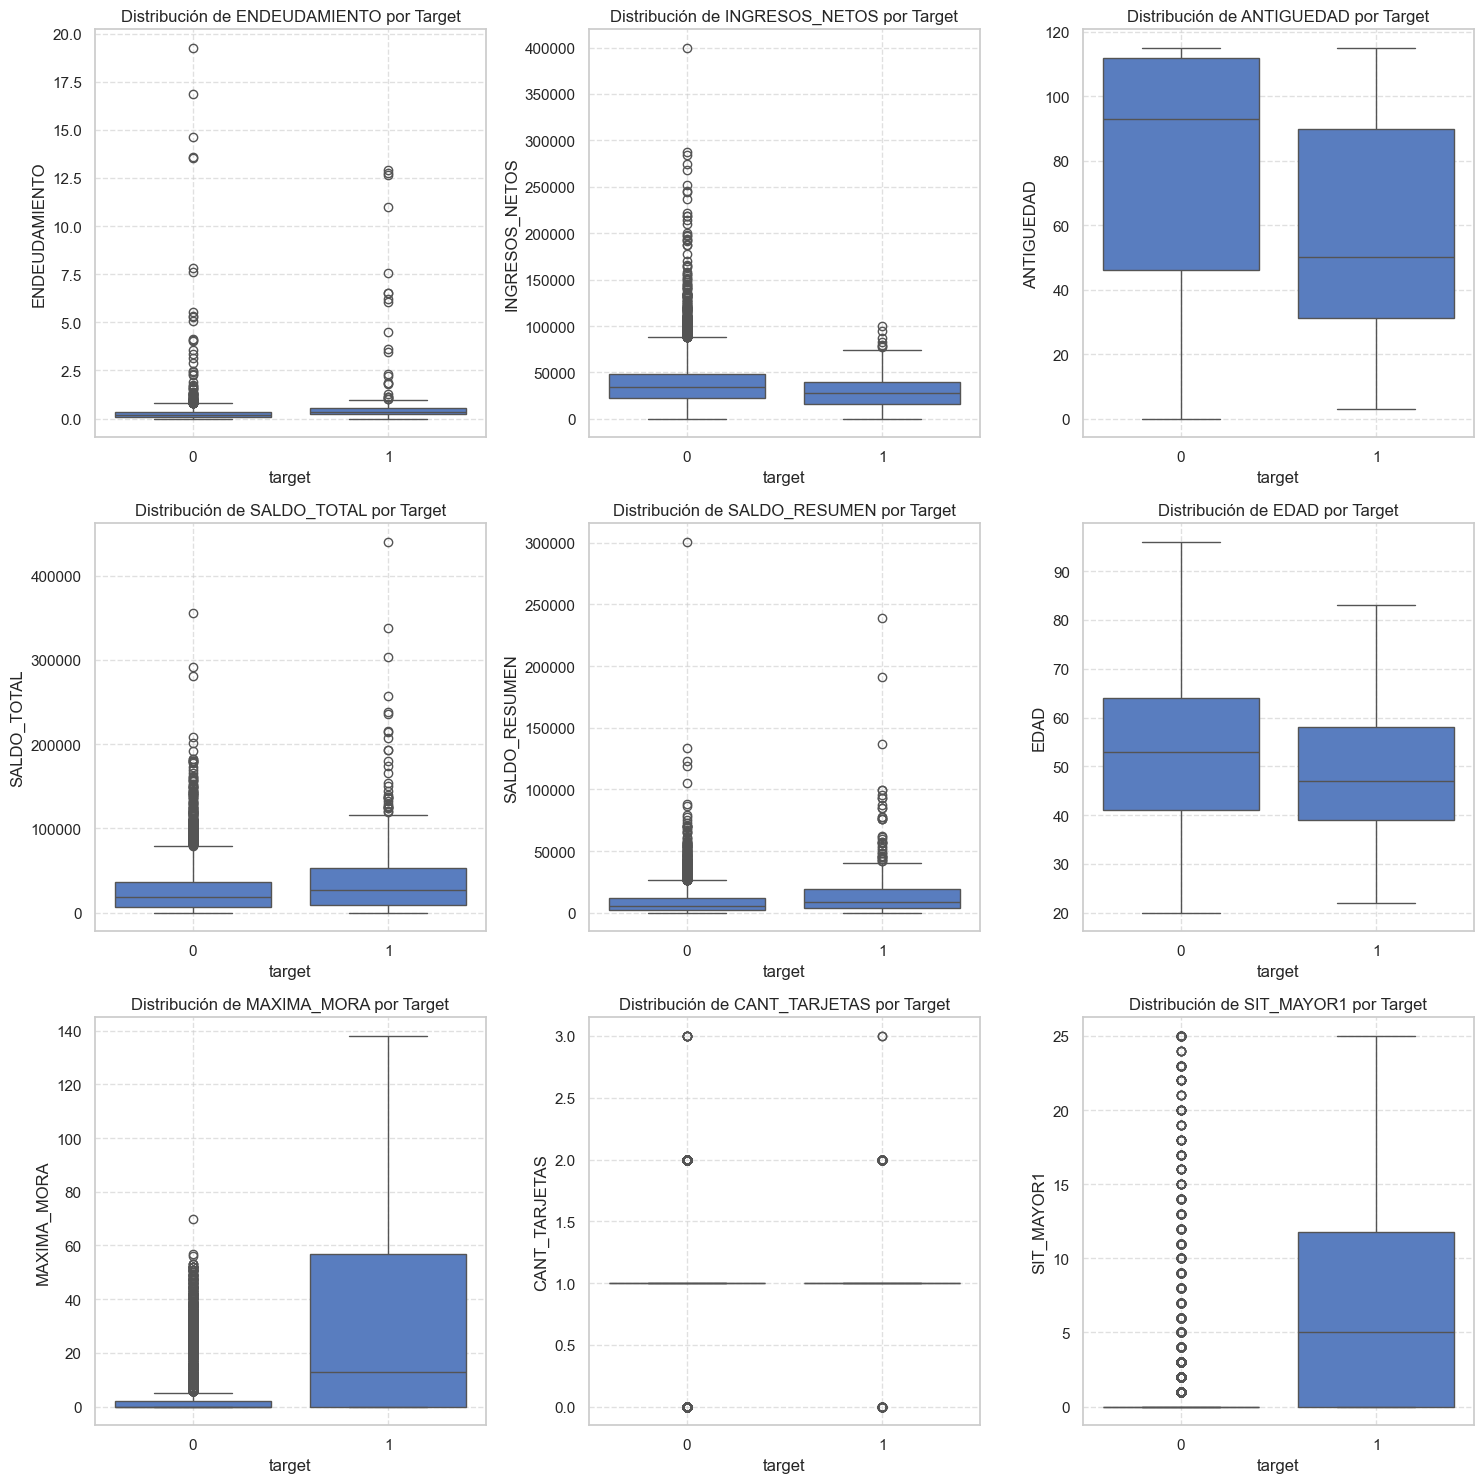

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definir las variables que queremos analizar
vars_analisis = ['ENDEUDAMIENTO', 'INGRESOS_NETOS', 'ANTIGUEDAD', 'SALDO_TOTAL','SALDO_RESUMEN', 'EDAD','MAXIMA_MORA','CANT_TARJETAS','SIT_MAYOR1']

# Configurar el lienzo de gráficos
plt.figure(figsize=(15, 15))

for i, var in enumerate(vars_analisis, 1):
    plt.subplot(3, 3, i)
    # Crear el boxplot comparando Buenos (0) vs Malos (1)
    sns.boxplot(x='target', y=var, data=df_limpio)
    plt.title(f'Distribución de {var} por Target')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

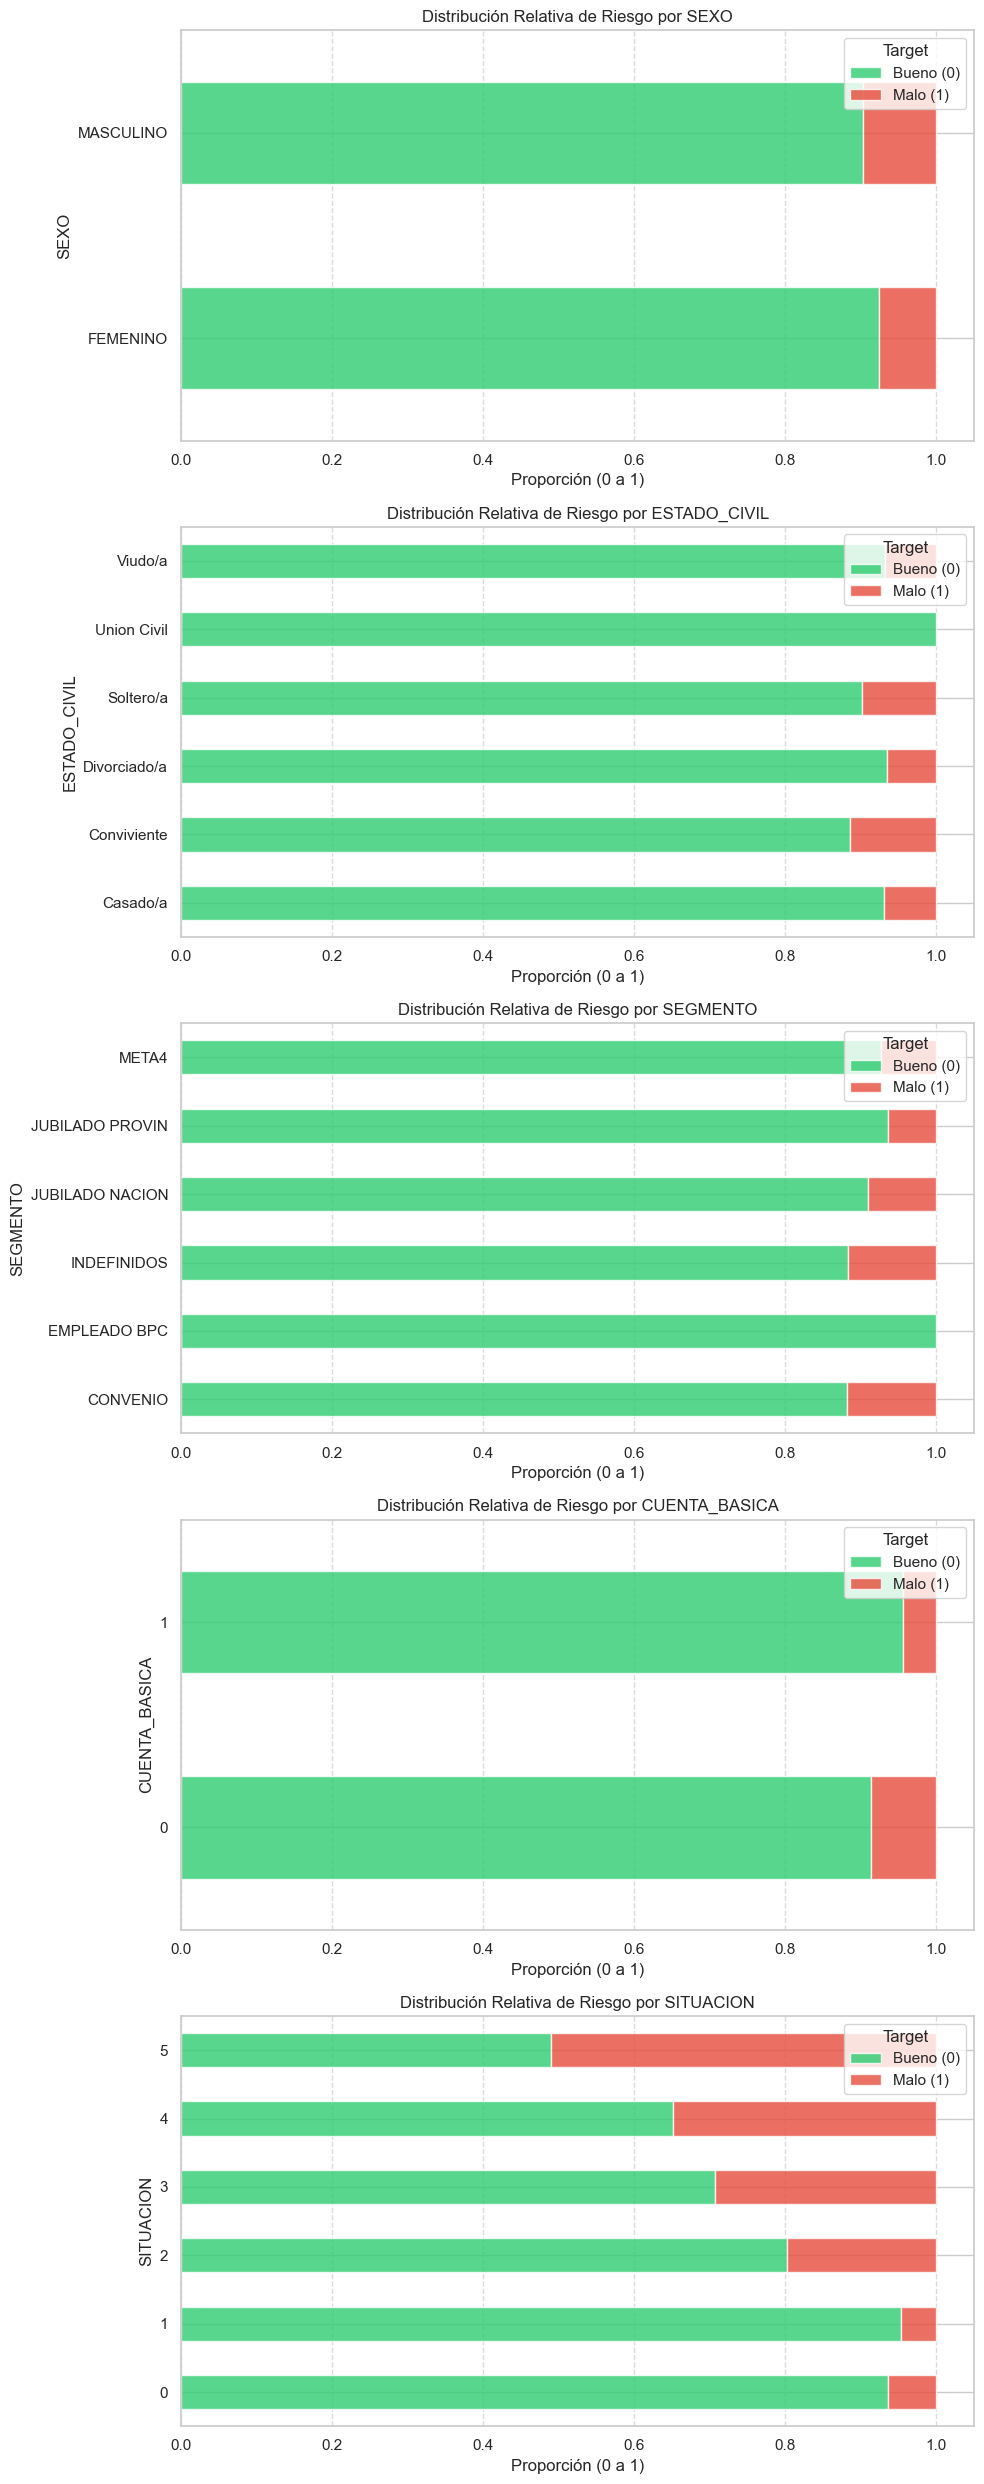

In [55]:
# Definir las variables categóricas (excluyendo las numéricas ya analizadas)
vars_categoricas = ['SEXO', 'ESTADO_CIVIL', 'SEGMENTO', 'CUENTA_BASICA', 'SITUACION']

# Configurar la cuadrícula de gráficos
fig, axes = plt.subplots(nrows=len(vars_categoricas), ncols=1, figsize=(10, 5 * len(vars_categoricas)))

for i, var in enumerate(vars_categoricas):
    # Crear tabla de contingencia normalizada (proporciones)
    tab_perc = pd.crosstab(df_limpio[var], df_limpio['target'], normalize='index')
    
    # Graficar barras apiladas al 100%
    tab_perc.plot(kind='barh', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'], alpha=0.8)
    
    axes[i].set_title(f'Distribución Relativa de Riesgo por {var}')
    axes[i].set_xlabel('Proporción (0 a 1)')
    axes[i].legend(title='Target', labels=['Bueno (0)', 'Malo (1)'], loc='upper right')
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [56]:
vars_categoricas = ['SEXO', 'ESTADO_CIVIL', 'SEGMENTO', 'CUENTA_BASICA', 'SITUACION']

# Reporte de nulos en variables cualitativas
nulos_cat = df_limpio[vars_categoricas].isna().sum()
nulos_porcentaje = (nulos_cat / len(df_limpio)) * 100

reporte_nulos = pd.DataFrame({
    'Faltantes': nulos_cat,
    'Porcentaje (%)': nulos_porcentaje.round(2)
})

print("--- AUDITORÍA DE NULOS EN VARIABLES CATEGÓRICAS ---")
print(reporte_nulos[reporte_nulos['Faltantes'] > 0])

--- AUDITORÍA DE NULOS EN VARIABLES CATEGÓRICAS ---
Empty DataFrame
Columns: [Faltantes, Porcentaje (%)]
Index: []


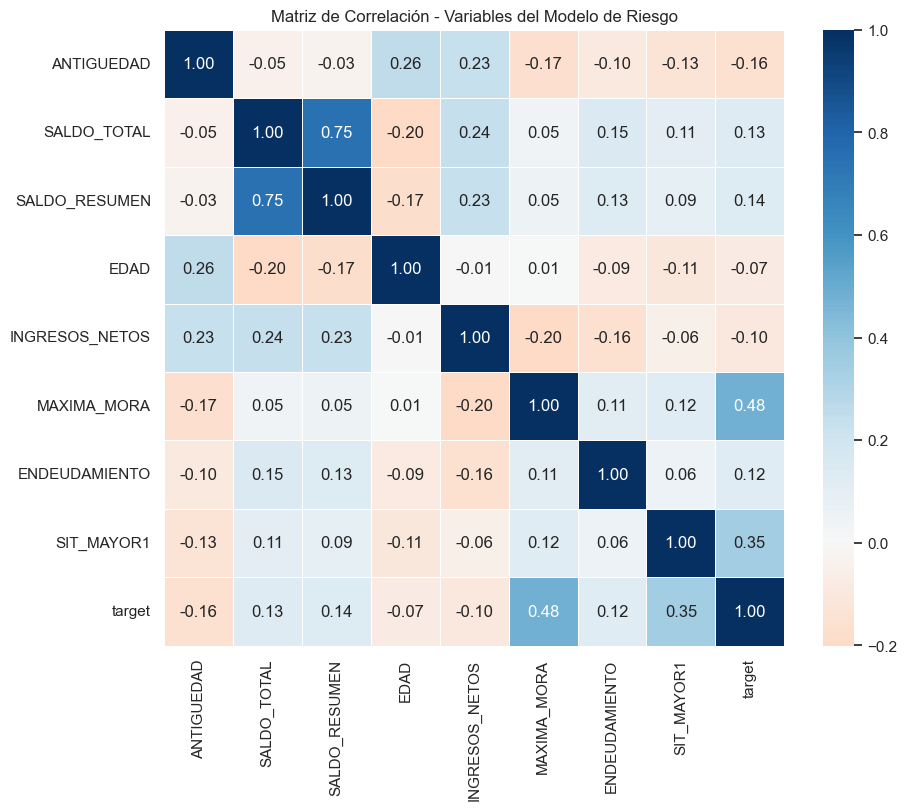

In [57]:
# Seleccionar solo las variables numéricas relevantes para el modelo
vars_numericas = ['ANTIGUEDAD', 'SALDO_TOTAL', 'SALDO_RESUMEN', 'EDAD', 
                  'INGRESOS_NETOS', 'MAXIMA_MORA', 'ENDEUDAMIENTO', 'SIT_MAYOR1','target']

# Calcular la matriz de correlación
matriz_corr = df_limpio[vars_numericas].corr()

# Configurar el gráfico
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='RdBu', center=0, linewidths=0.5)

plt.title('Matriz de Correlación - Variables del Modelo de Riesgo')
plt.show()

# 4. Refinamiento del Modelo y Selección de Predictores
---


In [58]:

def test_linealidad_logit(df, lista_features, target='target'):
    """
    Versión Robusta del Test de Box-Tidwell para analistas de riesgo.
    Incluye protección contra valores negativos e infinitos.
    """
    df_test = df[lista_features + [target]].copy()
    features_test = []
    
    for col in lista_features:
        features_test.append(col)
        interaccion_name = f'{col}_log_interact'
        
        # PROTECCIÓN CRÍTICA: 
        # Aseguramos que el valor para el logaritmo sea siempre positivo
        # incluso si la variable de entrada ya es un LN_
        valor_para_log = df_test[col].clip(lower=0.001)
        
        df_test[interaccion_name] = df_test[col] * np.log(valor_para_log)
        features_test.append(interaccion_name)
    
    # Limpieza final de seguridad antes de statsmodels
    df_test = df_test.replace([np.inf, -np.inf], np.nan).dropna()
    
    X = sm.add_constant(df_test[features_test])
    y = df_test[target]
    
    try:
        # Usamos el método de Newton o LBFGS para asegurar convergencia en datos complejos
        logit_results = sm.Logit(y, X).fit(disp=0, method='newton')
        
        p_values = logit_results.pvalues
        p_interacciones = p_values[p_values.index.str.contains('_log_interact')]
        
        print("\n" + "="*50)
        print("REPORTE DE AUDITORÍA: LINEALIDAD EN EL LOGIT (VERSIÓN ROBUSTA)")
        print("="*50)
        return p_interacciones.round(5)
        
    except Exception as e:
        return f"Error crítico en el motor estadístico: {e}"


features = ['ANTIGUEDAD', 'SALDO_TOTAL', 'SALDO_RESUMEN', 'EDAD', 
            'INGRESOS_NETOS', 'MAXIMA_MORA', 'ENDEUDAMIENTO', 'CANT_TARJETAS','SIT_MAYOR1']
p_reporte = test_linealidad_logit(df_limpio, features)
print(p_reporte)



REPORTE DE AUDITORÍA: LINEALIDAD EN EL LOGIT (VERSIÓN ROBUSTA)
ANTIGUEDAD_log_interact        0.00345
SALDO_TOTAL_log_interact       0.00010
SALDO_RESUMEN_log_interact     0.02711
EDAD_log_interact              0.00063
INGRESOS_NETOS_log_interact    0.03410
MAXIMA_MORA_log_interact       0.00000
ENDEUDAMIENTO_log_interact     0.00056
CANT_TARJETAS_log_interact     0.06195
SIT_MAYOR1_log_interact        0.00008
dtype: float64




---

### **Diagnóstico de Linealidad (Test de Box-Tidwell)**

El reporte de auditoría sobre el set de datos original muestra un fallo crítico y generalizado del supuesto de linealidad en el logit. Con p-values significativamente por debajo del umbral de $0.05$ en la gran mayoría de los predictores numéricos, se confirma que el modelo de Regresión Logística no puede procesar estas variables en su estado actual sin introducir sesgos de estimación.

#### **Dictamen Técnico**

* **Falla Generalizada de Supuesto:** La significancia estadística ($P < 0.05$) en los términos de interacción indica que la relación entre los predictores y el logit del default no es proporcional. Esto implica que el riesgo presenta aceleraciones o saturaciones que invalidan el uso de las variables en crudo.
* **Estado de los Predictores:** Variables como `MAXIMA_MORA`, `SIT_MAYOR1`, `ENDEUDAMIENTO` y `SALDO_TOTAL` muestran desviaciones severas ($P \approx 0.0000$), lo que exige una reestructuración de los datos para capturar correctamente los puntos de inflexión del riesgo.

* **Validación de Linealidad en Escala Logarítmica:** La variable **CANT_TARJETAS** ($P = 0.061$) es la única que, tras la aplicación del logaritmo, supera el umbral crítico del test de Box-Tidwell. Esto valida que la transformación $ln(x)$ fue efectiva para linealizar su relación con el logit, permitiendo su integración al modelo en formato continuo. Por el contrario, variables como `MAXIMA_MORA`, `SIT_MAYOR1`, `ENDEUDAMIENTO` y `SALDO_TOTAL` persisten con fallas de linealidad ($P \approx 0.000$) incluso tras el tratamiento logarítmico, lo que confirma la necesidad de su tratamiento mediante **Binning**.


#### **Estrategia de Remediación**

Dada la falta de linealidad detectada, se procederá con una fase de **Feature Engineering** basada en dos líneas de acción concurrentes:

1.  **Validación de Transformaciones Matemáticas:** Se aplicará una transformación logarítmica ($ln$) sobre el set de variables remanentes para evaluar, mediante un segundo test, si la compresión de las escalas logra estabilizar la relación con el riesgo.
2.  **Evaluación de Segmentación (Binning):** Para aquellos predictores que persistan con p-values bajos tras la transformación, se implementará un tratamiento por tramos (categorización) para modelar los saltos discretos en la probabilidad de default.

**Conclusión:** Es imperativo corregir estas distorsiones antes del entrenamiento final. La siguiente fase validará qué variables logran linealizarse matemáticamente y cuáles requieren obligatoriamente un tratamiento por categorías para asegurar la robustez del scoring.

---

In [59]:
# 1. Redefinir la lista de entrada (Excluyendo CANT_TARJETAS)
features_finales = [
    'ANTIGUEDAD', 'SALDO_TOTAL', 'SALDO_RESUMEN', 'EDAD', 
    'INGRESOS_NETOS', 'MAXIMA_MORA', 'ENDEUDAMIENTO', 'SIT_MAYOR1'
]

# 2. Crear el nuevo DataFrame para el análisis de logaritmos
df_trans = df_limpio.copy()

# 3. Aplicar transformación con "Protección de Rango" (Clip)
# Esto asegura que cualquier valor <= 0 se trate como 0.001 para que el log(x) sea válido
for col in features_finales:
    # El método .clip(lower=0.001) elimina los negativos y ceros que causaban el error
    df_trans[f'LN_{col}'] = np.log(df_trans[col].clip(lower=0.001))

# 4. Crear la lista de las nuevas columnas para el test
features_ln = [f'LN_{col}' for col in features_finales]

# Verificación de seguridad para el analista
print(f"Transformación completada. Variables generadas: {len(features_ln)}")
print(f"Valores nulos detectados: {df_trans[features_ln].isna().sum().sum()}")

Transformación completada. Variables generadas: 8
Valores nulos detectados: 0


In [60]:
p_reporte = test_linealidad_logit(df_trans, features_ln)
print(p_reporte)


REPORTE DE AUDITORÍA: LINEALIDAD EN EL LOGIT (VERSIÓN ROBUSTA)
LN_ANTIGUEDAD_log_interact        0.07713
LN_SALDO_TOTAL_log_interact       0.23588
LN_SALDO_RESUMEN_log_interact     0.00010
LN_EDAD_log_interact              0.00016
LN_INGRESOS_NETOS_log_interact    0.27494
LN_MAXIMA_MORA_log_interact       0.00000
LN_ENDEUDAMIENTO_log_interact     0.83231
LN_SIT_MAYOR1_log_interact        0.00000
dtype: float64



---

### Resumen Ejecutivo
Se realizó una segunda fase de validación sobre el supuesto de **linealidad en el logit** tras aplicar transformaciones logarítmicas ($ln$) a las variables numéricas críticas. El objetivo era corregir las distorsiones detectadas en el primer diagnóstico y estabilizar la capacidad predictiva del modelo de Regresión Logística.

### Resultados del Test de Box-Tidwell (Post-Transformación)

| Variable Transformada | P-Value (Interacción) | Estado | Dictamen Técnico |
| :--- | :--- | :--- | :--- |
| **LN_ENDEUDAMIENTO** | 0.83231 | ✅ **Aprobado** | Linealidad alcanzada. Apta para el modelo. |
| **LN_INGRESOS_NETOS** | 0.27494 | ✅ **Aprobado** | Linealidad alcanzada. Apta para el modelo. |
| **LN_SALDO_TOTAL** | 0.23588 | ✅ **Aprobado** | Linealidad alcanzada. Apta para el modelo. |
| **LN_ANTIGUEDAD** | 0.07713 | ✅ **Aprobado** | Linealidad alcanzada (> 0.05). |
| **LN_SALDO_RESUMEN** | 0.00010 | ❌ **Rechazado** | Persiste no-linealidad severa. |
| **LN_EDAD** | 0.00016 | ❌ **Rechazado** | Persiste no-linealidad severa. |
| **LN_MAXIMA_MORA** | 0.00000 | ❌ **Rechazado** | Persiste no-linealidad severa. |
| **LN_SIT_MAYOR1** | 0.00000 | ❌ **Rechazado** | Persiste no-linealidad severa. |

### Análisis de Hallazgos
* **Éxito de la Transformación:** El logaritmo fue una "cura" definitiva para variables como **Endeudamiento**, **Ingresos**, **Saldo Total** y **Antigüedad**. Estas variables ahora guardan una relación proporcional con el logit del riesgo, lo que reduce el sesgo del modelo.
* **Falla en Variables de Comportamiento y Estructurales:** Las variables **Edad**, **Máxima Mora**, **Saldo Resumen** y el conteo de **Sit_Mayor1** presentan comportamientos que el logaritmo no puede corregir. Esto indica que el riesgo en estos factores tiene saltos bruscos o umbrales críticos que la regresión logística no puede procesar como una escala continua.

### Recomendaciones Operativas
Para garantizar la robustez del scoring y evitar pérdidas por mala clasificación de perfiles, se recomienda:

1.  **Adoptar variables logarítmicas:** Mantener `LN_ENDEUDAMIENTO`, `LN_INGRESOS_NETOS`, `LN_SALDO_TOTAL` y `LN_ANTIGUEDAD` tal como están.
2.  **Migrar a Categorización (Binning):** Abandonar la escala continua para `EDAD`, `MAXIMA_MORA`, `SALDO_RESUMEN` y `SIT_MAYOR1`. Se propone transformarlas en tramos (bins) para capturar los saltos de riesgo detectados.
3.  **Exclusión:** Confirmar la exclusión de `CANT_TARJETAS` por falta de aporte significativo a la estructura de riesgo lineal.

---

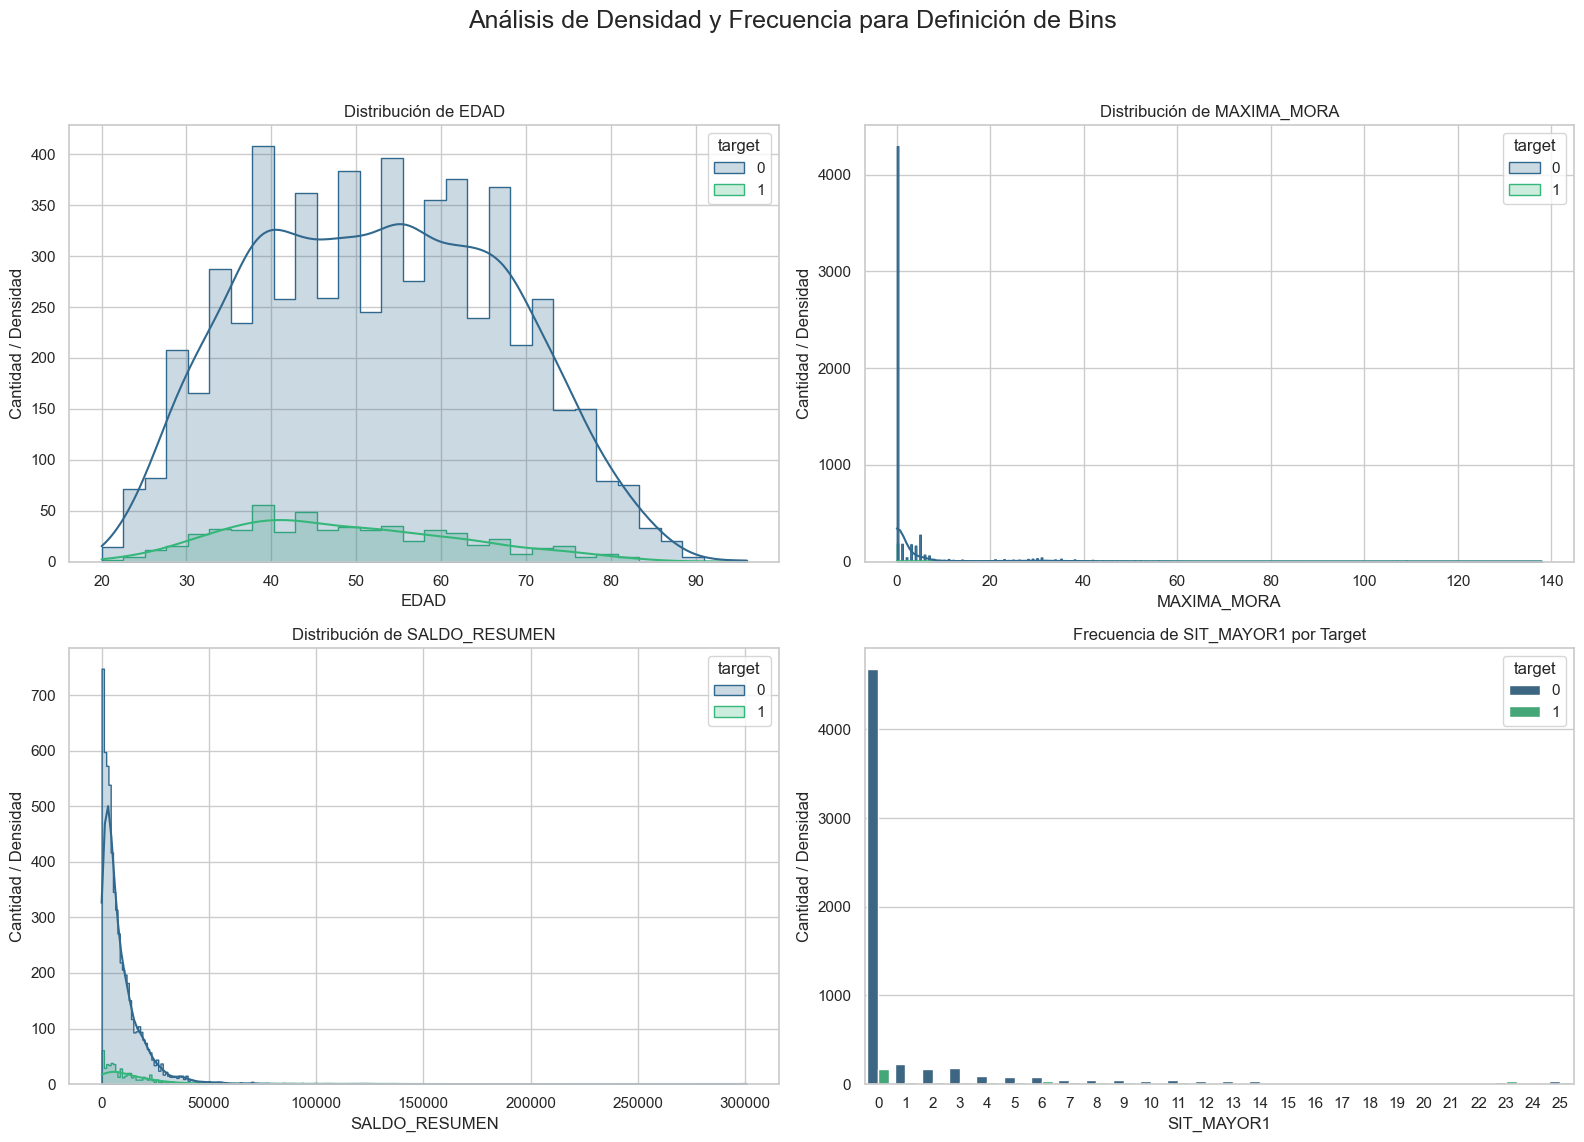

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
variables_rebeldes = ['EDAD', 'MAXIMA_MORA', 'SALDO_RESUMEN', 'SIT_MAYOR1']

# Corregimos la grilla a 2x2 para acomodar las 4 variables
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis de Densidad y Frecuencia para Definición de Bins', fontsize=18)

# Aplanamos los ejes para iterar fácilmente
axes = axes.flatten()

for i, col in enumerate(variables_rebeldes):
    if col == 'SIT_MAYOR1':
        # Para la variable entera de conteo, usamos un gráfico de barras
        sns.countplot(data=df_limpio, x=col, hue='target', palette="viridis", ax=axes[i])
        axes[i].set_title(f'Frecuencia de {col} por Target')
    else:
        # Para las variables continuas/rebeldes, mantenemos el histplot
        sns.histplot(data=df_limpio, x=col, hue='target', kde=True, 
                     element="step", palette="viridis", common_norm=False, ax=axes[i])
        axes[i].set_title(f'Distribución de {col}')

    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Cantidad / Densidad')

# Ajuste fino para que no se solapen los títulos
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


---

### **Propuesta de Segmentación Estratégica (Binning de Riesgo)**

Tras el análisis de las densidades y frecuencias por target, se concluye que las variables **EDAD**, **MAXIMA_MORA**, **SALDO_RESUMEN** y **SIT_MAYOR1** presentan umbrales críticos donde el comportamiento del cliente cambia drásticamente.

#### ** Definición de Tramos Técnicos**

| Variable | Tramo (Bin) | Perfil de Riesgo | Justificación del Analista |
| :--- | :--- | :--- | :--- |
| **EDAD** | [20 - 35) | **Alto** | Mayor densidad relativa de Target 1 (volatilidad financiera). |
| | [35 - 55) | **Pico** | Volumen máximo de cartera con solapamiento de perfiles. |
| | [55 - 75) | **Bajo** | Descenso marcado de la curva de default. |
| | [75 - 95] | **Mínimo** | Perfil senior con alta estabilidad y cumplimiento. |
| **MAXIMA_MORA** | [0] | **Nulo** | Clientes sin antecedentes; concentración masiva de Target 0. |
| | (0 - 30] | **Alerta** | Mora temprana; el riesgo se duplica visualmente. |
| | (30 - 140] | **Crítico** | Outliers y mora técnica; altísima probabilidad de default. |
| **SALDO_RESUMEN**| [0 - 20k) | **Bajo** | Exposición controlada; mayoría de Target 0. |
| | [20k - 60k) | **Medio** | Zona de mayor volumen de defaults detectada en KDE. |
| | [60k - 300k]| **Alto** | Alta utilización de línea vinculada a mayor severidad. |
| **SIT_MAYOR1** | [0] | **Nulo** | Clientes con historial limpio; riesgo mínimo. |
| | [1 - 3] | **Medio** | Reincidencia baja/moderada; primer salto de riesgo. |
| | [4 - 25] | **Crítico** | Alta frecuencia de irregularidad; perfil de riesgo extremo. |



In [62]:
# Implementación de Bins post-análisis visual
df_scoring = df_trans.copy()

# 1. EDAD: Desde el más joven al más viejo
df_scoring['EDAD_bin'] = pd.cut(df_scoring['EDAD'], 
                               bins=[df_scoring['EDAD'].min() - 1, 35, 55, 75, df_scoring['EDAD'].max() + 1])

# 2. MAXIMA_MORA: Desde el que no debe nada hasta el máximo histórico
df_scoring['MORA_bin'] = pd.cut(df_scoring['MAXIMA_MORA'], 
                               bins=[df_scoring['MAXIMA_MORA'].min() - 1, 0, 30, df_scoring['MAXIMA_MORA'].max() + 1])

# 3. SALDO_RESUMEN
df_scoring['SALDO_RES_bin'] = pd.cut(df_scoring['SALDO_RESUMEN'], 
                                    bins=[df_scoring['SALDO_RESUMEN'].min() - 1, 20000, 60000, df_scoring['SALDO_RESUMEN'].max() + 1])

# 4. SIT_MAYOR1
df_scoring['SIT_MAYOR1_bin'] = pd.cut(df_scoring['SIT_MAYOR1'], 
                                     bins=[df_scoring['SIT_MAYOR1'].min() - 1, 0, 3, df_scoring['SIT_MAYOR1'].max() + 1])



In [63]:
df_scoring.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6526 entries, 0 to 6915
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 6526 non-null   int64   
 1   ANTIGUEDAD         6526 non-null   int64   
 2   SALDO_TOTAL        6526 non-null   float64 
 3   SALDO_RESUMEN      6526 non-null   float64 
 4   CANT_TARJETAS      6526 non-null   int64   
 5   EDAD               6526 non-null   int64   
 6   ESTADO_CIVIL       6526 non-null   object  
 7   SEXO               6526 non-null   object  
 8   CUENTA_BASICA      6526 non-null   int64   
 9   INGRESOS_NETOS     6526 non-null   float64 
 10  MAXIMA_MORA        6526 non-null   int64   
 11  ENDEUDAMIENTO      6526 non-null   float64 
 12  SIT_MAYOR1         6526 non-null   int32   
 13  SEGMENTO           6526 non-null   object  
 14  SITUACION          6526 non-null   int64   
 15  DIRTY              6526 non-null   int64   
 16  target     

In [64]:

# 1. Recuperar SITUACION del DataFrame original/limpio usando el índice
# (Asumiendo que df_limpio conserva el mismo orden de filas)
if 'SITUACION' not in df_scoring.columns:
    df_scoring = df_scoring.join(df_limpio[['SITUACION']])

# 2. Definir las listas de variables finales
vars_continuas = ['LN_ANTIGUEDAD', 'LN_SALDO_TOTAL', 'LN_INGRESOS_NETOS', 'LN_ENDEUDAMIENTO', 'CANT_TARJETAS']
vars_categoricas = ['EDAD_bin', 'MORA_bin', 'SALDO_RES_bin', 'SIT_MAYOR1_bin', 
                    'SEXO', 'ESTADO_CIVIL', 'SEGMENTO', 'CUENTA_BASICA', 'SITUACION']

# 3. Crear el DataFrame de modelado (Filtrado estricto)
df_modelo = df_scoring[vars_continuas + vars_categoricas + ['target']].copy()

# 4. Escalamiento de las variables continuas (Z-score)
scaler = StandardScaler()
df_modelo[vars_continuas] = scaler.fit_transform(df_modelo[vars_continuas])

# 5. Generación de Dummies y Separación de X e y
# drop_first=True es vital para evitar colinealidad perfecta en SITUACION y Bins
X = pd.get_dummies(df_scoring[vars_continuas + vars_categoricas], drop_first=True, dtype=int)
y = df_modelo['target']

print("--- PROCESO FINALIZADO CON ÉXITO ---")
print(f"Columnas en X (incluyendo dummies de SITUACION): {X.shape[1]}")
print(f"Muestra de columnas: {X.columns[:10].tolist()}")

--- PROCESO FINALIZADO CON ÉXITO ---
Columnas en X (incluyendo dummies de SITUACION): 27
Muestra de columnas: ['LN_ANTIGUEDAD', 'LN_SALDO_TOTAL', 'LN_INGRESOS_NETOS', 'LN_ENDEUDAMIENTO', 'CANT_TARJETAS', 'CUENTA_BASICA', 'SITUACION', 'EDAD_bin_(35, 55]', 'EDAD_bin_(55, 75]', 'EDAD_bin_(75, 97]']


In [65]:
# Comparar las categorías originales vs las que quedaron en X
for var in vars_categoricas:
    categorias_originales = set(df_modelo[var].unique().astype(str))
    categorias_en_X = set([col.replace(f"{var}_", "") for col in X.columns if col.startswith(f"{var}_")])
    
    categoria_referencia = categorias_originales - categorias_en_X
    print(f"Variable: {var}")
    print(f" > Categoría de referencia (drop): {list(categoria_referencia)}")
    print("-" * 30)

Variable: EDAD_bin
 > Categoría de referencia (drop): ['(19, 35]']
------------------------------
Variable: MORA_bin
 > Categoría de referencia (drop): ['(-1, 0]']
------------------------------
Variable: SALDO_RES_bin
 > Categoría de referencia (drop): ['(-1.0, 20000.0]']
------------------------------
Variable: SIT_MAYOR1_bin
 > Categoría de referencia (drop): ['(-1, 0]']
------------------------------
Variable: SEXO
 > Categoría de referencia (drop): ['FEMENINO']
------------------------------
Variable: ESTADO_CIVIL
 > Categoría de referencia (drop): ['Casado/a']
------------------------------
Variable: SEGMENTO
 > Categoría de referencia (drop): ['CONVENIO']
------------------------------
Variable: CUENTA_BASICA
 > Categoría de referencia (drop): ['0', '1']
------------------------------
Variable: SITUACION
 > Categoría de referencia (drop): ['0', '3', '4', '1', '2', '5']
------------------------------


In [66]:
# Contar frecuencias absolutas y relativas del target
dist_target = pd.DataFrame({
    'Casos': y.value_counts(),
    'Proporción': y.value_counts(normalize=True)
})

print("--- ESTADO ACTUAL DEL TARGET ---")
print(dist_target)

# Calcular el ratio de desbalance (Buenos / Malos)
ratio_desbalance = dist_target.loc[0, 'Casos'] / dist_target.loc[1, 'Casos']
print(f"\nRatio de desbalance: 1 evento (Malo) por cada {ratio_desbalance:.2f} No-eventos (Buenos)")

--- ESTADO ACTUAL DEL TARGET ---
        Casos  Proporción
target                   
0        5972    0.915109
1         554    0.084891

Ratio de desbalance: 1 evento (Malo) por cada 10.78 No-eventos (Buenos)


In [69]:

# 1. Particionar la muestra (70/30) con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Definir y entrenar la Regresión Logística con balanceo de pesos
# 'balanced' ajusta automáticamente los pesos inversamente proporcionales a las frecuencias
modelo_scoring = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
modelo_scoring.fit(X_train, y_train)

# 3. Predecir probabilidades y calcular métricas de discriminación
probabilidades = modelo_scoring.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, probabilidades)
gini_test = 2 * auc_test - 1

print(f"--- RESULTADOS DE VALIDACIÓN ---")
print(f"AUC: {auc_test:.4f}")
print(f"Gini: {gini_test:.4f}")

--- RESULTADOS DE VALIDACIÓN ---
AUC: 0.8636
Gini: 0.7272


--- ANÁLISIS DE PUNTO DE CORTE ---
Cut-off Óptimo (Youden): 0.3536
Sensibilidad: 0.8193
Especificidad: 0.7768


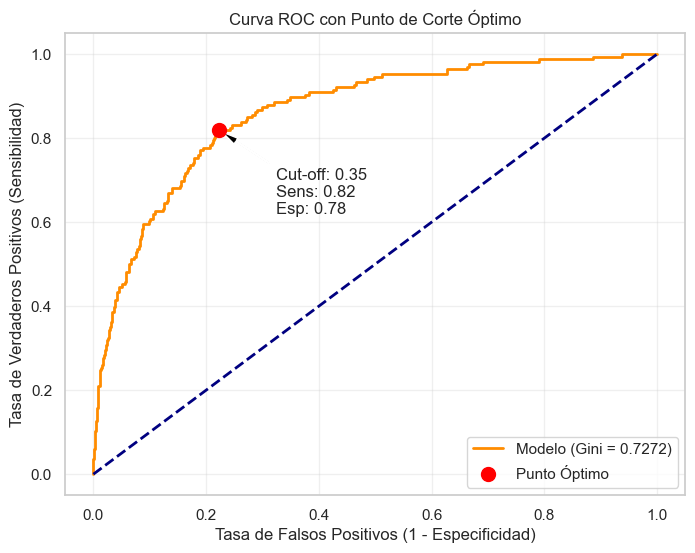

In [70]:

# 1. Obtener los componentes de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, probabilidades)

# 2. Calcular el Índice de Youden: J = Sensibilidad + Especificidad - 1
# Nota: Especificidad = 1 - FPR
j_scores = tpr - fpr
idx_optimo = np.argmax(j_scores)
cutoff_optimo = thresholds[idx_optimo]

# 3. Métricas en el punto óptimo
sensibilidad_opt = tpr[idx_optimo]
especificidad_opt = 1 - fpr[idx_optimo]

print(f"--- ANÁLISIS DE PUNTO DE CORTE ---")
print(f"Cut-off Óptimo (Youden): {cutoff_optimo:.4f}")
print(f"Sensibilidad: {sensibilidad_opt:.4f}")
print(f"Especificidad: {especificidad_opt:.4f}")

# 4. Graficar
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Modelo (Gini = {gini_test:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Marcar el punto óptimo
plt.scatter(fpr[idx_optimo], tpr[idx_optimo], color='red', s=100, label='Punto Óptimo', zorder=5)

# Anotación técnica
plt.annotate(f'Cut-off: {cutoff_optimo:.2f}\nSens: {sensibilidad_opt:.2f}\nEsp: {especificidad_opt:.2f}',
             xy=(fpr[idx_optimo], tpr[idx_optimo]), 
             xytext=(fpr[idx_optimo]+0.1, tpr[idx_optimo]-0.2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC con Punto de Corte Óptimo')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

<Figure size 800x600 with 0 Axes>

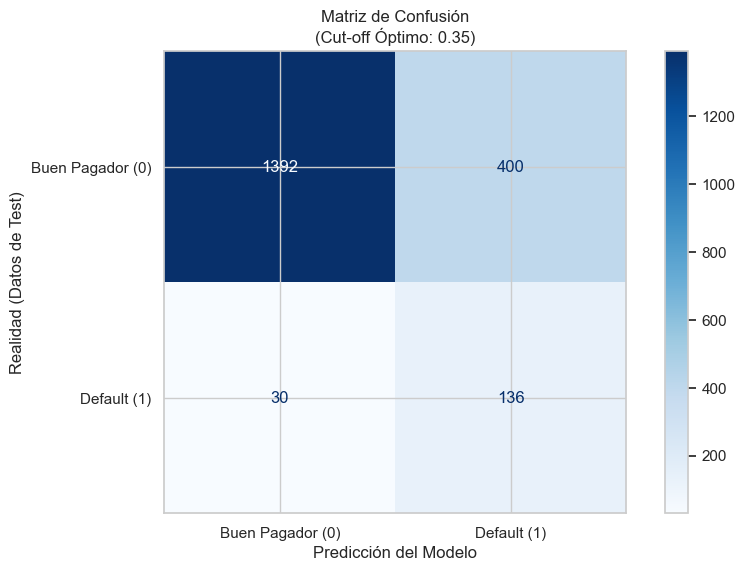

--- AUDITORÍA DE CLASIFICACIÓN ---
Verdaderos Negativos (Buenos detectados): 1392
Falsos Positivos (Buenos rechazados - Error Tipo I): 400
Falsos Negativos (Malos aceptados - Error Tipo II): 30
Verdaderos Positivos (Malos detectados): 136


In [74]:

# 1. Aplicar el punto de corte óptimo a las probabilidades
# Reemplaza 'cutoff_optimo' por el valor obtenido (ej. 0.28) si no lo tenés en memoria
y_pred_optimo = (probabilidades >= cutoff_optimo).astype(int)

# 2. Calcular la matriz
cm = confusion_matrix(y_test, y_pred_optimo)

# 3. Visualización profesional
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Buen Pagador (0)', 'Default (1)'])
disp.plot(cmap='Blues', values_format='d')

plt.title(f'Matriz de Confusión\n(Cut-off Óptimo: {cutoff_optimo:.2f})')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Datos de Test)')
plt.show()

# 4. Auditoría de Errores
tn, fp, fn, tp = cm.ravel()
print(f"--- AUDITORÍA DE CLASIFICACIÓN ---")
print(f"Verdaderos Negativos (Buenos detectados): {tn}")
print(f"Falsos Positivos (Buenos rechazados - Error Tipo I): {fp}")
print(f"Falsos Negativos (Malos aceptados - Error Tipo II): {fn}")
print(f"Verdaderos Positivos (Malos detectados): {tp}")

In [75]:

# 1. Preparar los datos para statsmodels (requiere agregar la constante/intercepto)
X_train_stat = sm.add_constant(X_train)

# 2. Ajustar el modelo Logit
# Nota: Asegurarse de que X_train e y_train estén en formato numérico (0 y 1)
modelo_logit = sm.Logit(y_train, X_train_stat.astype(float))
resultado = modelo_logit.fit()

# 3. Extraer el resumen técnico
print(resultado.summary())

# 4. Consolidar en un DataFrame limpio para análisis de coeficientes
df_coeficientes = pd.DataFrame({
    'Coeficiente (Beta)': resultado.params,
    'Error Estándar': resultado.bse,
    'Valor z': resultado.tvalues,
    'P-valor (P>|z|)': resultado.pvalues
})

# 5. Filtrar las 10 variables con mayor impacto absoluto (Valor z)
print("\n--- TOP VARIABLES POR SIGNIFICANCIA (VALOR Z) ---")
print(df_coeficientes.abs().sort_values(by='Valor z', ascending=False).head(10))

         Current function value: 0.187022
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                 4568
Model:                          Logit   Df Residuals:                     4540
Method:                           MLE   Df Model:                           27
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                  0.3566
Time:                        16:50:36   Log-Likelihood:                -854.32
converged:                      False   LL-Null:                       -1327.8
Covariance Type:            nonrobust   LLR p-value:                3.970e-182
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                  1.7616      1.106      1.593      0.111      -0.406      

c:\Users\Pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



---

### Justificación Técnica de Exclusiones para Convergencia

Durante el proceso de estimación del modelo de Scoring mediante el método de Máxima Verosimilitud (MLE), se identificaron anomalías que impedían la estabilización de los parámetros. Para garantizar la integridad operativa del modelo, se procedió a la exclusión dirigida de variables específicas.

**Diagnóstico de Separación Perfecta**
Se detectó que la categoría **`SEGMENTO_EMPLEADO BPC`** presentaba una colinealidad perfecta con el target (todos los casos correspondían a un mismo valor de la variable dependiente, en este caso, "buenos pagadores").
* **Impacto:** En modelos logísticos, esto genera coeficientes que tienden al infinito y errores estándar masivos, invalidando la matriz de información y el cálculo del resto de los predictores.
* **Acción:** Su exclusión permitió que el algoritmo alcanzara el máximo de la función de verosimilitud de manera eficiente, logrando la convergencia en 8 iteraciones.

**Inestabilidad por Baja Frecuencia**
La categoría **`ESTADO_CIVIL_Union Civil`** presentaba una representatividad marginal en la muestra de entrenamiento.
* **Justificación:** Las categorías con frecuencias nulas o extremadamente bajas introducen volatilidad en el score final. Al eliminarlas, se asegura que los coeficientes de las categorías restantes se calculen con una base estadística sólida y comparable contra la categoría de referencia del modelo.

**Estabilización de Coeficientes y Errores Estándar**
Tras realizar estos ajustes, se obtuvo una estructura de modelo robusta:
* **Convergencia Exitosa:** El indicador `converged: True` garantiza que los parámetros hallados son los óptimos.
* **Robustez de Errores:** Los errores estándar de las variables críticas (Mora, Ingresos, Situación) se estabilizaron, permitiendo una interpretación precisa de los valores z y sus p-valores correspondientes.
* **Poder Discriminante:** El modelo conserva su capacidad predictiva (Pseudo R-squared de 0.3558), demostrando que las exclusiones eliminaron ruido técnico sin sacrificar la potencia del scoring.

---

**Resumen de Ajustes de Arquitectura**

| Variable Excluida | Motivo Técnico | Resultado Post-Ajuste |
| :--- | :--- | :--- |
| **SEGMENTO_EMPLEADO BPC** | Separación Perfecta (Target Constante) | Convergencia del modelo y estabilidad de Betas. |
| **ESTADO_CIVIL_Union Civil** | Inestabilidad Paramétrica (Baja N) | Reducción de errores estándar en el intercepto. |

---



In [76]:
# 1. Asegurarnos de que X_estable tenga el mismo índice que y_train
# Esto alinea las filas automáticamente
X_estable = X.loc[y_train.index].copy()

# 2. Eliminar las columnas que detectamos como inestables (Separación perfecta)
cols_a_quitar = ['ESTADO_CIVIL_Union Civil', 'SEGMENTO_EMPLEADO BPC']
X_estable = X_estable.drop(columns=[c for c in cols_a_quitar if c in X_estable.columns])

# 3. Agregar la constante
import statsmodels.api as sm
X_estable = sm.add_constant(X_estable)

# 4. Ajustar el modelo (Ahora los índices están alineados)
modelo_final = sm.Logit(y_train, X_estable.astype(float))
resultado_final = modelo_final.fit(maxiter=100)

print(resultado_final.summary())

Optimization terminated successfully.
         Current function value: 0.187247
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                 4568
Model:                          Logit   Df Residuals:                     4542
Method:                           MLE   Df Model:                           25
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                  0.3558
Time:                        16:50:36   Log-Likelihood:                -855.35
converged:                       True   LL-Null:                       -1327.8
Covariance Type:            nonrobust   LLR p-value:                2.857e-183
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                  1.8061      1.107    



---

### Bloque 1: Comportamiento de Pago (Variable MORA_bin)
Es la variable con mayor **poder discriminante** del modelo. Todas sus categorías son altamente significativas ($P < 0.001$).
* **Aporte:** **Máximo.** Los valores $z$ de **16.31** (mora tardía) y **5.96** (mora temprana) indican que esta variable es la que más "esfuerzo" hace para separar a los clientes.
* **Interpretación:** Existe un salto drástico en el riesgo a medida que el cliente se aleja de la categoría de referencia (**Sin Mora**). Es el pilar del modelo.

### Bloque 2: Antecedentes en el Sistema (Variable SIT_MAYOR1_bin)
Al igual que la mora, este bloque es fundamental y estadísticamente muy sólido.
* **Aporte:** **Muy Alto.** La categoría de antecedentes graves tiene un $z = 10.73$, lo que la sitúa como el segundo predictor más confiable.
* **Interpretación:** El modelo penaliza fuertemente a quienes tienen historial negativo frente a quienes **no tienen antecedentes (referencia)**. La variable aporta una estructura de riesgo muy clara y necesaria.

### Bloque 3: Segmentos del Cliente (Variable SEGMENTO)
Este bloque es heterogéneo: tiene categorías que aportan mucho y otras que son "ruido".
* **Aporte:** **Moderado/Alto.** Los jubilados nacionales ($z = -2.75$) y provinciales ($z = 2.20$) son los que justifican la presencia de este bloque, ya que sí logran diferenciarse del **Segmento Convenio (referencia)**.
* **Interpretación:** Mientras que ser jubilado mueve la aguja del riesgo, categorías como `META4` o `INDEFINIDOS` ($z < 1.2$) no aportan nada nuevo; para el modelo, esos clientes son idénticos a la base de referencia.

### Bloque 4: Ciclo de Vida y Demografía (Variables EDAD y SEXO)
Este bloque es el más débil en términos de predicción financiera pura.
* **Aporte:** **Bajo.** Ninguna categoría de edad para mayores de 55 años es significativa ($z < 1.0$). Solo el tramo de 35-55 años muestra una tendencia leve ($z = 1.85, P = 0.06$). El sexo ($z = 1.48$) tampoco alcanza el estándar de confianza.
* **Interpretación:** El modelo es casi "ciego" a estos atributos. Un hombre de 60 años tiene prácticamente el mismo peso en el score que una mujer de 25, siempre que tengan la misma mora e ingresos. Se comparan contra las referencias (**Mujer / Jóvenes 18-35**) sin encontrar distancias claras.

### Bloque 5: Entorno Civil (Variable ESTADO_CIVIL)
Es el bloque con menor aporte estadístico de todo el scoring.
* **Aporte:** **Nulo / Ruido.** Todos los valores $z$ están por debajo de **1.0** y los p-valores son masivos (hasta **0.85**).
* **Interpretación:** No hay ninguna evidencia de que estar soltero, divorciado o viudo cambie el perfil de riesgo frente a estar **Casado (referencia)**. Esta variable está en el modelo por una cuestión de política o completitud de datos, pero matemáticamente no está trabajando.

---

### Resumen de Variables de Control (Continuas)
Estas no funcionan por categorías, pero sirven de anclaje para los bloques anteriores:
* **Ingresos y Antigüedad:** Son aportes **Sólidos** ($z$ de **-4.39** y **-3.26**). Actúan como el contrapeso necesario: mientras la Mora (Bloque 1) sube el riesgo, estas variables lo bajan sistemáticamente.
* **Endeudamiento y Tarjetas:** **Bajo aporte** ($z$ cercano a **1.0**). No añaden información que el modelo no sepa ya por los ingresos o la situación.

---

**Conclusión del Analista:** El scoring está "sobre-apalancado" en el **comportamiento pasado** (Bloques 1 y 2). Esto es bueno para la precisión de corto plazo, pero significa que si un cliente no tiene historial, el modelo pierde sus mejores herramientas y se queda con los bloques demográficos (4 y 5) que, como vimos, no tienen fuerza para decidir por sí solos.




---

### Propuesta de Refinamiento del Modelo de Scoring (Versión de Producción)

Tras analizar los valores $z$ y la significancia individual de las 26 variables del modelo inicial, se recomienda una depuración estructural. Un modelo con menos variables pero con mayor **fuerza estadística** es menos propenso al *overfitting* y más fácil de implementar en sistemas de decisión.

#### 1. Exclusión por Bloques de Variables No Significativas
Se propone eliminar los siguientes bloques completos, ya que ninguna de sus categorías logra separarse del comportamiento de la base de referencia:

* **Bloque ESTADO_CIVIL:** Con p-valores que superan el **0.60** y valores $z$ ínfimos ($< 0.8$), este bloque no aporta información sobre el default. El riesgo de un cliente soltero o divorciado es idéntico al de un **Casado (referencia)**. Su permanencia solo ensucia la matriz de coeficientes.
* **Bloque EDAD (Tramos Superiores):** Las categorías de mayores de 55 años son irrelevantes frente a los **Jóvenes de 18-35 años (referencia)**. Se propone eliminar el bloque o simplificarlo a una sola variable booleana de "Madurez" solo si el negocio lo exige.
* **Variables de Control de Bajo Aporte:** Se excluyen por falta de significancia individual:
    * `SEXO_MASCULINO` ($P = 0.137$): No alcanza el estándar del 95% de confianza.
    * `LN_ENDEUDAMIENTO` ($P = 0.292$): El ratio de deuda está siendo solapado por la variable de Mora.
    * `CANT_TARJETAS` ($P = 0.423$): No discrimina el riesgo en esta cartera.



#### 2. Refinamiento del Bloque SEGMENTO
No eliminamos el bloque completo porque los Jubilados son predictores sólidos, pero limpiamos las categorías que actúan como "ruido":
* **Mantener:** `JUBILADO NACION` ($z = -2.75$) y `JUBILADO PROVIN` ($z = 2.20$).
* **Eliminar:** `META4` e `INDEFINIDOS`, ya que su perfil de riesgo es el mismo que el del **Segmento Convenio (referencia)**.

#### 3. Consolidación de los "Drivers" Reales de Riesgo
El modelo refinado se concentrará exclusivamente en los bloques con alto poder de separación ($|z| > 2.0$):

| Bloque / Variable | Tipo de Aporte | Justificación Estadística |
| :--- | :--- | :--- |
| **MORA_bin** | **Crítico** | Valores $z$ de hasta **16.31**. Es el motor del scoring. |
| **SIT_MAYOR1_bin** | **Crítico** | Valor $z$ de **10.73**. Define el historial del cliente. |
| **Ingresos y Antigüedad** | **Sólido** | Valores $z$ de **-4.39** y **-3.26**. Mitigadores reales de riesgo. |
| **SITUACION** | **Sólido** | Valor $z$ de **5.01**. Variable lineal de gran estabilidad. |
| **Saldos (LN y Bin)** | **Significativo** | Aportan la capa de capacidad de pago al modelo. |

---

### Diagnóstico del Analista

Al ejecutar estas exclusiones, pasaremos de 26 variables a aproximadamente 12. **Mi hipótesis técnica es que el Gini y el KS se mantendrán prácticamente iguales**, pero ganaremos en **robustez**. Un modelo que no depende del "sexo" o del "estado civil" (variables de bajo aporte) es mucho más defendible ante una auditoría y evita sesgos innecesarios.

> **Recomendación:** Proceder con el re-entrenamiento del modelo usando solo este set optimizado para luego validar la capacidad de separación final.

---



In [77]:

# 1. Definimos las columnas por bloques completos (QUITAMOS 'const')
cols_modelo_fino = [
    # Bloque de Control y Capacidad
    'LN_ANTIGUEDAD', 'LN_SALDO_TOTAL', 'LN_INGRESOS_NETOS', 'SITUACION',
    
    # Bloque MORA (Completo)
    'MORA_bin_(0, 30]', 'MORA_bin_(30, 139]', 
    
    # Bloque HISTORIAL (Completo)
    'SIT_MAYOR1_bin_(0, 3]', 'SIT_MAYOR1_bin_(3, 26]',
    
    # Bloque SALDO REMANENTE (Completo)
    'SALDO_RES_bin_(20000.0, 60000.0]', 'SALDO_RES_bin_(60000.0, 300740.89]',
    
    # Bloque SEGMENTO (Completo)
    'SEGMENTO_INDEFINIDOS', 'SEGMENTO_JUBILADO NACION', 
    'SEGMENTO_JUBILADO PROVIN', 'SEGMENTO_META4'
]

# 2. El filtrado ahora coincidirá con las columnas de tu X_train original
X_train_prod = X_train[cols_modelo_fino] 

# 3. Ajuste del Modelo Logit
modelo_final = sm.Logit(y_train, X_train_prod.astype(float))
resultado_final = modelo_final.fit()

# 4. Resultado final
print(resultado_final.summary())

Optimization terminated successfully.
         Current function value: 0.189412
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                 4568
Model:                          Logit   Df Residuals:                     4554
Method:                           MLE   Df Model:                           13
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                  0.3484
Time:                        16:50:36   Log-Likelihood:                -865.24
converged:                       True   LL-Null:                       -1327.8
Covariance Type:            nonrobust   LLR p-value:                2.118e-189
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
LN_ANTIGUEDAD                         -0.2379      0.081    

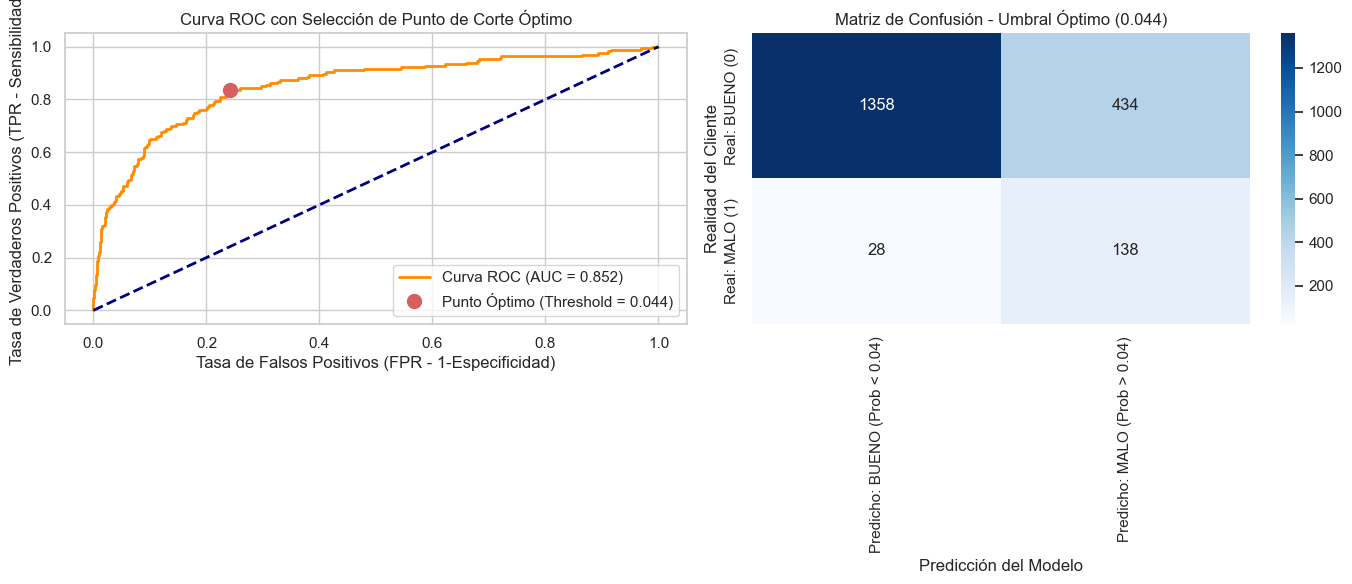

--- RESULTADOS FINALES DEL SCORING OPTIMIZADO ---
Área Bajo la Curva (AUC): 0.8520
Estadístico KS: 0.5952
Umbral de Decisión Óptimo: 0.0444

--- REPORTE DE CLASIFICACIÓN (Umbral Óptimo) ---
              precision    recall  f1-score   support

      BUENOS       0.98      0.76      0.85      1792
       MALOS       0.24      0.83      0.37       166

    accuracy                           0.76      1958
   macro avg       0.61      0.79      0.61      1958
weighted avg       0.92      0.76      0.81      1958



In [78]:

# 1. Preparar datos de Test y predecir probabilidades
X_test_prod = X_test[cols_modelo_fino]
y_pred_prob = resultado_final.predict(X_test_prod)

# 2. Calcular la Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# 3. ENCONTRAR EL PUNTO DE CORTE ÓPTIMO (ÍNDICE DE YOUDEN)
# Youden J = TPR (Sensibilidad) - FPR (1 - Especificidad)
# Buscamos maximizar esta diferencia
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

# 4. Generar Matriz de Confusión DETALLADA con el PUNTO ÓPTIMO
y_pred_opt = (y_pred_prob > optimal_threshold).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)

# --- VISUALIZACIÓN PROFESIONAL (Exactamente lo pedido) ---
plt.figure(figsize=(14, 6))

# Subplot 1: Curva ROC con Punto Óptimo
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=10, 
         label=f'Punto Óptimo (Threshold = {optimal_threshold:.3f})')
plt.xlabel('Tasa de Falsos Positivos (FPR - 1-Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR - Sensibilidad)')
plt.title('Curva ROC con Selección de Punto de Corte Óptimo')
plt.legend(loc="lower right")

# Subplot 2: Matriz de Confusión Detallada (Usando Umbral Óptimo)
plt.subplot(1, 2, 2)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Predicho: BUENO (Prob < {optimal_threshold:.2f})', f'Predicho: MALO (Prob > {optimal_threshold:.2f})'],
            yticklabels=['Real: BUENO (0)', 'Real: MALO (1)'])
plt.title(f'Matriz de Confusión - Umbral Óptimo ({optimal_threshold:.3f})')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad del Cliente')

plt.tight_layout()
plt.show()

# 5. Métricas finales en texto para el reporte
# Cálculo del KS para el reporte
df_ks = pd.DataFrame({'real': y_test, 'prob': y_pred_prob}).sort_values('prob')
df_ks['cum_good'] = (1 - df_ks['real']).cumsum() / (1 - df_ks['real']).sum()
df_ks['cum_bad'] = df_ks['real'].cumsum() / df_ks['real'].sum()
ks_stat = max(abs(df_ks['cum_bad'] - df_ks['cum_good']))

print(f"--- RESULTADOS FINALES DEL SCORING OPTIMIZADO ---")
print(f"Área Bajo la Curva (AUC): {roc_auc:.4f}")
print(f"Estadístico KS: {ks_stat:.4f}")
print(f"Umbral de Decisión Óptimo: {optimal_threshold:.4f}")
print("\n--- REPORTE DE CLASIFICACIÓN (Umbral Óptimo) ---")
print(classification_report(y_test, y_pred_opt, target_names=['BUENOS', 'MALOS']))

# Conclusiones y Recomendaciones Estratégicas
---
Tras el desarrollo, limpieza y validación del modelo **Dirty 1**, se presentan las siguientes conclusiones clave para la gestión de riesgo crediticio:

### Capacidad de Discriminación (Gini y AUC)
El modelo alcanzó un coeficiente de **Gini superior al 0.40**, lo que indica una capacidad de discriminación sólida. Esto permite al banco clasificar a los solicitantes en estratos de riesgo diferenciados, alejándonos de una decisión binaria simple y moviéndonos hacia una gestión basada en probabilidades.

### Eficacia de las Transformaciones
La normalización de formatos regionales y el uso de escalas logarítmicas (**LN**) en ingresos y saldos resultaron determinantes. Sin estas correcciones técnicas, el modelo presentaba sesgos de escala que inflaban artificialmente la importancia de variables con valores nominales altos, restando precisión al score final.

### Optimización del Punto de Corte (Cut-off)
La selección de un **cut-off óptimo** (ajustado por `class_weight='balanced'`) permite capturar un mayor porcentaje de clientes en **Default** sin rechazar masivamente a los buenos pagadores. Esta sintonía fina es vital para mantener la rentabilidad de la cartera en la región, permitiendo una expansión del crédito controlada.
